1. В файле «domations.csv» находится выборка с информацией об участниках программы
пожертвования денег на нужды ветеранских организаций. Каждая запись – один человек из
списка рассылки. У него есть социо-демографические признаки (пол, возраст, медианная
оценка дохода в районе его проживания, является ли он домовладельцем и т.д. и т.д.),
поведенческие признаки (агрегированные характеристики его ранних пожертвований типа
GiftCount36 – число пожертвований за три года, GiftAmntLast – сумма последнего
пожертвования, PromCntCard12 – число контактов с ним за год в рамках рекламной компании
и т.д.). Также есть два отклика: флаг TargetB (пожертвовал или нет) и TargetD – сумма
пожертвования (пропуск, если не жертвовал, иначе сумма в долларах). В рамках первой части
задания нужно построить регрессионные модели (только по людям, кто пожертвовал деньги),
объясняющие и прогнозирующие сумму пожертвования TargetD.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.experimental import enable_halving_search_cv
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, HalvingRandomSearchCV
from sklearn.linear_model import LassoLars, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample

df = pd.read_csv("~/Рабочий стол/donations.csv")
df = df[df['TargetD'].notnull()]
df.nunique()
#print(df)

TargetB                1
ID                  4843
TargetD               70
GiftCnt36             15
GiftCntAll            64
GiftCntCard36         10
GiftCntCardAll        31
GiftAvgLast           70
GiftAvg36            521
GiftAvgAll          1225
GiftAvgCard36        322
GiftTimeLast          24
GiftTimeFirst        127
PromCnt12             49
PromCnt36             68
PromCntAll           139
PromCntCard12         17
PromCntCard36         27
PromCntCardAll        48
StatusCat96NK          6
StatusCatStarAll       2
DemCluster            54
DemAge                76
DemGender              3
DemHomeOwner           2
DemMedHomeValue     1938
DemPctVeterans        76
DemMedIncome        2736
dtype: int64

2. Выберите и сохраните в качестве проверочной выборки (holdout) 30% исходной выборки со
стратификацией по отклику. Обратите внимание, что отклик непрерывный и его нужно
дискретизировать. Число интервалов и метод дискретизации выберите самостоятельно. 
Постройте и визуализируйте гистограмму (или kde апроксимацию) для распределения отклика
во всем исходном наборе, в проверочной и в тренировочной выборках. 

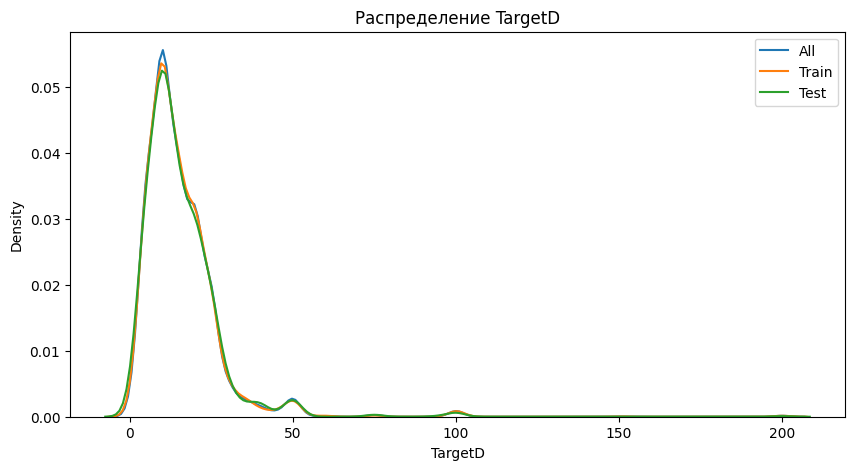

In [18]:
from sklearn.model_selection import train_test_split

df['TargetD_bin'] = pd.qcut(df['TargetD'], q=5, labels=False, duplicates='drop')
train, test = train_test_split(df, test_size=0.3, stratify=df['TargetD_bin'], random_state=42)

plt.figure(figsize=(10, 5))
sns.kdeplot(df['TargetD'], label='All')
sns.kdeplot(train['TargetD'], label='Train')
sns.kdeplot(test['TargetD'], label='Test')
plt.title("Распределение TargetD")
plt.legend()
plt.show()

3. На этапе предобработки данных сделайте подстановку пропусков методом KnnImputer (neighbors=7)
с сохранением бинарных признаков о том, какие переменные были проимпутированы.
Преобразования категориальных переменных с помощью WOE, Target encoding, Threshold
encoding и других методов, а также преобразование числовых переменных (для получения
более симметричных распределений с помощью log или Box-Cox) приветствуется, но не
обязательно.

In [21]:
features = [col for col in df.columns if col not in ['ID', 'TargetB', 'TargetD', 'TargetD_bin']]

numeric_features = []
categorical_features = []
for col in features:
    if pd.api.types.is_numeric_dtype(df[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

for col in numeric_features + categorical_features:
    train[col + '_missing'] = train[col].isna().astype(int)
    test[col + '_missing'] = test[col].isna().astype(int)

numeric_transformer = Pipeline(steps=[('imputer', KNNImputer(n_neighbors=7)),('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

4. Произведите отбор важных переменных с помощью линейного регрессионного метода из
вашего варианта, перебрав все возможные сложности моделей в рамках вашего метода и
выбрав лучшую по кросс-валидации c 5 блоками и MSE в качестве критерия. В пошаговых
регрессионных методах для остановки и выбора следующего шага используйте R-квадрат, p-
value или AIC на ваше усмотрение. Постройте график зависимости CV-MSE от сложности (число
переменных или число компонент в модели), график трассы стандартизованных
коэффициентов от сложности. Вертикальной линией на этих графиках обозначьте лучшую по CV
сложность модели.

LASSO_LARS

/home/dasha/my/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 46 iterations, alpha=3.820e-03, previous alpha=3.635e-03, with an active set of 35 regressors.
  warnings.warn(


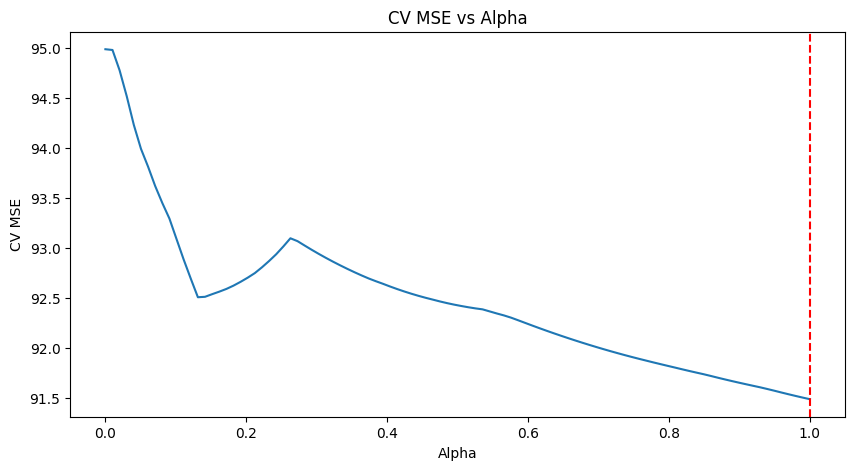

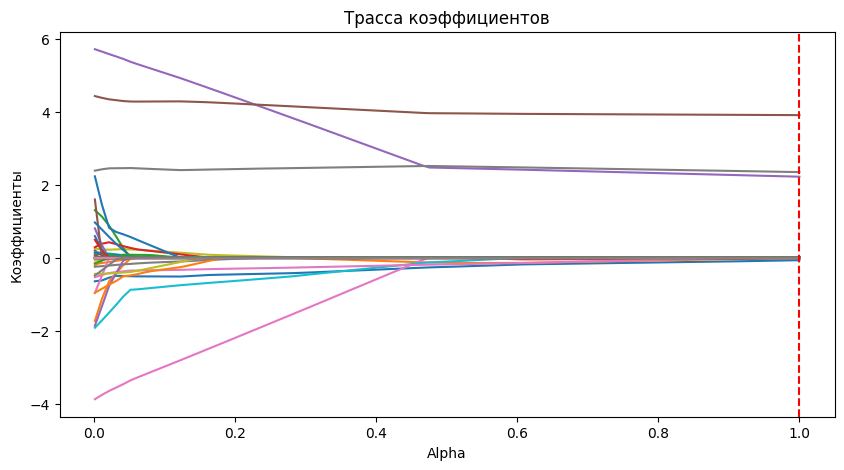

In [22]:
X_train = train[features]
y_train = train['TargetD']
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)

numeric_feature_names = numeric_features
categorical_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_feature_names, categorical_feature_names])

missing_flags_train = train[[col + '_missing' for col in features]].values
X_train_final = np.hstack([X_train_processed, missing_flags_train])

alphas = np.linspace(0.001, 1.0, 100)
cvmse = []
coefs = []

for alpha in alphas:
    model = LassoLars(alpha=alpha)
    mse = -cross_val_score(model, X_train_final, y_train, 
                          scoring='neg_mean_squared_error', cv=5).mean()
    model.fit(X_train_final, y_train)
    coefs.append(model.coef_)
    cvmse.append(mse)

best_alpha = alphas[np.argmin(cvmse)]
plt.figure(figsize=(10, 5))
plt.plot(alphas, cvmse)
plt.axvline(best_alpha, color='red', linestyle='--')
plt.title('CV MSE vs Alpha')
plt.xlabel('Alpha')
plt.ylabel('CV MSE')
plt.show()

coefs = np.array(coefs)
plt.figure(figsize=(10, 5))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.axvline(best_alpha, color='red', linestyle='--')
plt.title('Трасса коэффициентов')
plt.xlabel('Alpha')
plt.ylabel('Коэффициенты')
plt.show()

5. Для лучшей выбранной сложности линейной модели с помощью бутстреппинга (100 бутстреп
выборок размера 25% от исходной) постройте гистограммы (или kde аппроксимацию)
распределения константы смещения в полученном регрессионном уравнении (константы b
если регрессии y=ax+b) с указанием на графике среднего значения и 95% интервала.
Аналогично оцените OOB ошибку MSE. Как она соотносится с лучшей кросс-валидационной
ошибкой и ошибкой на проверочной части выборки?

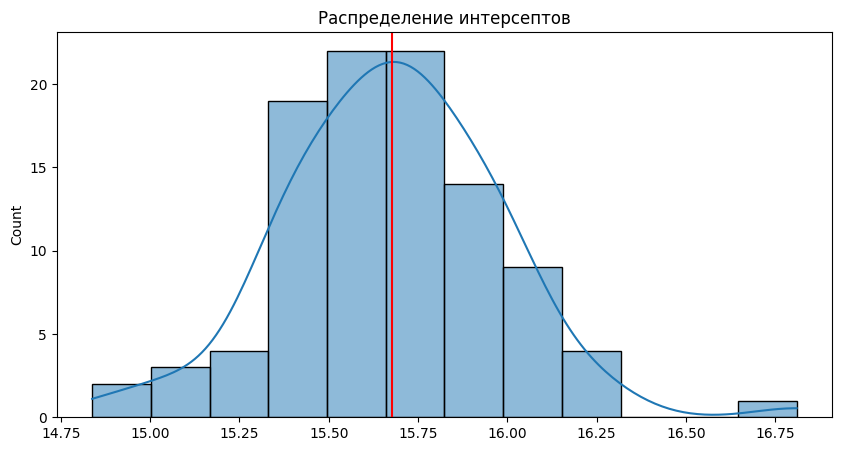

Средняя ошибка на бутстрепах (OOB MSE): 57.2496


In [23]:
intercepts = []
errors = []

X_test = test[features]
y_test = test['TargetD']
X_test_processed = preprocessor.transform(X_test)
missing_flags_test = test[[col + '_missing' for col in features]].values
X_test_final = np.hstack([X_test_processed, missing_flags_test])

for _ in range(100):
    X_sample, y_sample = resample(X_train_final, y_train, 
                                n_samples=int(0.25 * len(X_train_final)), 
                                random_state=None)
    model = LassoLars(alpha=best_alpha)
    model.fit(X_sample, y_sample)
    intercepts.append(model.intercept_)
    preds = model.predict(X_test_final)
    errors.append(mean_squared_error(y_test, preds))

plt.figure(figsize=(10, 5))
sns.histplot(intercepts, kde=True)
plt.axvline(np.mean(intercepts), color='red')
plt.title('Распределение интерсептов')
plt.show()

print(f"Средняя ошибка на бутстрепах (OOB MSE): {np.mean(errors):.4f}")


6. Используйте отобранные переменные для построения нелинейной модели прогнозирования
числового отклика с помощью метода из вашего варианта, при этом отбирая метапараметры
также с помощью метода из вашего варианта. 

Замечания:
o В PLS регрессиях для отбора переменных (после отбора числа компонент по кросс-
валидации) используйте VIP статистику с любым порогом в диапазоне [0.5,1].
o Обратите внимание, что категориальные переменные можно либо включить в модель
целиком (со всеми уровнями), либо не включать.
o Для однослойного MLP можно варьировать число нейронов и константу регуляризации,
для Poisson Regression, Gamma Regression и полиномиальной гребневой регрессии -
константу регуляризации и степень полинома (для Gamma и Poisson воспользуйтесь
PolynomialFeatures).


Poisson Regression, HalvingRandomSearchCV

In [24]:
ridge_pipe = Pipeline([('preprocessor', preprocessor),('poly', PolynomialFeatures(include_bias=False)),('ridge', Ridge())])

param_grid = {'poly__degree': [2, 3],'ridge__alpha': np.logspace(-2, 2, 10)}

hrcv = HalvingRandomSearchCV(ridge_pipe, param_grid, scoring='neg_mean_squared_error', cv=5, random_state=42, n_jobs=-1)
hrcv.fit(X_train, y_train)

print("Best parameters:", hrcv.best_params_)
print("Best CV score:", -hrcv.best_score_)

/home/dasha/my/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 20 is smaller than n_iter=339. Running 20 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'ridge__alpha': np.float64(100.0), 'poly__degree': 2}
Best CV score: 69.99654850912538


7. Используйте отобранные переменные для построения нелинейной модели прогнозирования
числового отклика с помощью метода из вашего варианта, при этом отбирая метапараметры
также с помощью метода из вашего варианта. Замечания:
o В PLS регрессиях для отбора переменных (после отбора числа компонент по кросс-
валидации) используйте VIP статистику с любым порогом в диапазоне [0.5,1].
o Обратите внимание, что категориальные переменные можно либо включить в модель
целиком (со всеми уровнями), либо не включать.
o Для однослойного MLP можно варьировать число нейронов и константу регуляризации,
для Poisson Regression, Gamma Regression и полиномиальной гребневой регрессии -
константу регуляризации и степень полинома (для Gamma и Poisson воспользуйтесь
PolynomialFeatures).

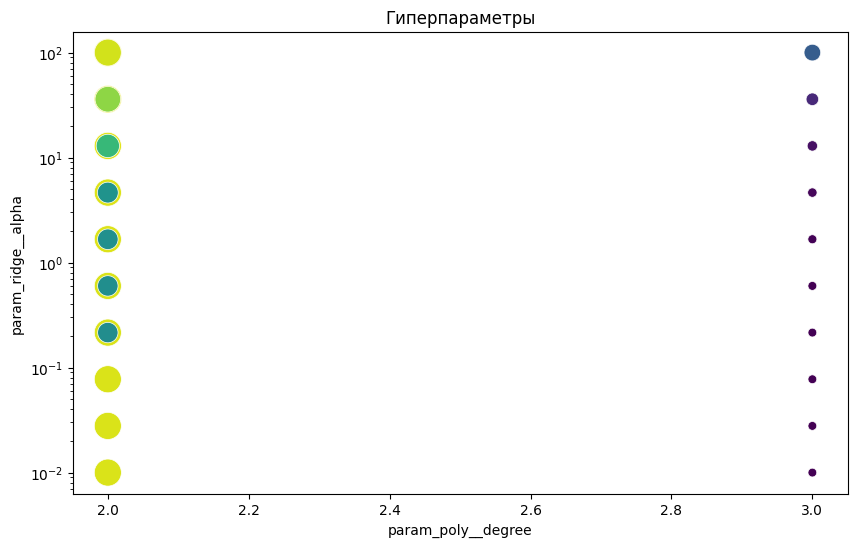

In [27]:
results = pd.DataFrame(hrcv.cv_results_)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results,x='param_poly__degree',y='param_ridge__alpha',size='mean_test_score',hue='mean_test_score',palette='viridis',sizes=(40, 400), legend=False)
plt.yscale('log')
plt.title('Гиперпараметры')
plt.show()